In [1]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
from copy import deepcopy
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import DeepBurstDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config
from matplotlib import rcParams, rcParamsDefault
import matplotlib.colors as mcolors


torch.autograd.set_detect_anomaly(True)


EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniconda3/envs/deepburst/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)


In [3]:
targets=['bf_label','bs_label']
with open('benchmarks/revised_v2/reviewer3/results/bs_bf_threshold_analysis_indicators.csv','w') as w:
    line = ['eid','fold','auc','target','infer_method','threshold_method']
    w.write(','.join(line) + '\n')
    for eid in ["E003","E118","E116"]:    
            for fold in [0,1,2,3]:
                checkpoints = f"benchmarks/revised_v2/reviewer3/checkpoints/{eid}.threshold.txburst.fold.{fold}.bs_bf_para.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                for target in targets:
                    auc = ckpt[f"{target}_val_auc"]
                    line = [eid,str(fold),str(auc),target,'txburst','mean_threshold']
                    w.write(','.join(line) + '\n')
                checkpoints = f"benchmarks/revised_v2/reviewer3/checkpoints/{eid}.threshold_median_exclude_mid20.txburst.fold.{fold}.bs_bf_para.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                for target in targets:
                    auc = ckpt[f"{target}_val_auc"]
                    line = [eid,str(fold),str(auc),target,'txburst','exclude_mid20']
                    w.write(','.join(line) + '\n')


data = pd.read_csv('benchmarks/revised_v2/reviewer3/results/bs_bf_threshold_analysis_indicators.csv')
data


data_baseline = pd.read_csv('extra/results/bs_bf_para_indicators.csv')

In [4]:
data_baseline = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
data_baseline['threshold_method'] = 'median'
data.drop(columns=['infer_method'],inplace=True)
indicators = pd.concat([data,data_baseline],axis=0)
indicators


,eid,fold,auc,target,threshold_method
0,E003,0,86.248188,bf_label,mean_threshold
1,E003,0,80.070762,bs_label,mean_threshold
2,E003,0,96.349020,bf_label,exclude_mid20
3,E003,0,89.643146,bs_label,exclude_mid20
4,E003,1,86.790904,bf_label,mean_threshold
...,...,...,...,...,...
19,E003,1,94.033919,bf_label,median
20,E003,2,82.337164,bs_label,median
21,E003,2,93.607921,bf_label,median
22,E003,3,81.204227,bs_label,median


# origin txburst

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_25448/3459521804.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[idx].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_25448/3459521804.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[idx].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_25448/3459521804.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


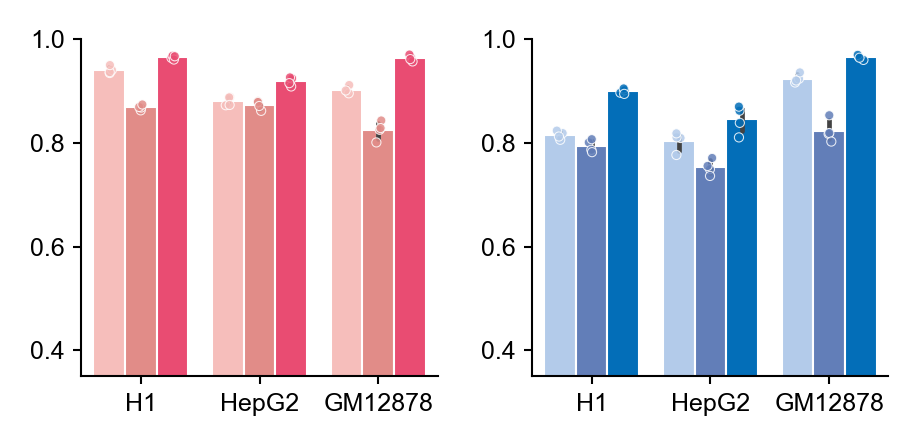

In [5]:
targets=['bf_label','bs_label']
data = pd.read_csv('benchmarks/revised_v2/reviewer3/results/bs_bf_threshold_analysis_indicators.csv')
data_baseline = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
data_baseline['threshold_method'] = 'median'
data.drop(columns=['infer_method'],inplace=True)
indicators = pd.concat([data,data_baseline],axis=0)

indicators['auc'] = indicators['auc']/100

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(8/2.54, 4/2.54))


palette = ['#E94C72','#036EB8','#036EB8']

order=['E003','E118','E116',]
hue_order=['median','mean_threshold','exclude_mid20',]


palette_dict = {'bf_label': ['#F6BEBB',"#E18C88","#E94C72"],'bs_label': ['#B3CBEA',"#627EB8","#036EB8"]}


for idx, target in enumerate(targets):
    sns.barplot(data=indicators[indicators['target']==target],
                x='eid',
                y='auc',
                hue='threshold_method',
                ax=ax[idx],
                order=order,
                hue_order=hue_order,
                palette=palette_dict[target],
                width=0.8,alpha=1.0,saturation=1,linewidth=0.5
                )
    sns.stripplot(
        data=indicators[indicators['target']==target],
        x="eid",
        y="auc",
        hue='threshold_method',
        order=order,
        hue_order=hue_order,
        palette=palette_dict[target],
        dodge=True,
        jitter=0.08,
        size=2.2,
        alpha=0.85,
        linewidth=0.25,
        edgecolor="white",
        ax=ax[idx],
        legend=False,
    )
        # Show the plot
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(ymin=0.35, ymax=1.0)
    ax[idx].legend().remove()
    ax[idx].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)

plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer3/figures/threshold_analysis_txburst.pdf", format='pdf', bbox_inches='tight')
plt.show()


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74521/1895246477.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74521/1895246477.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74521/1895246477.py:149: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


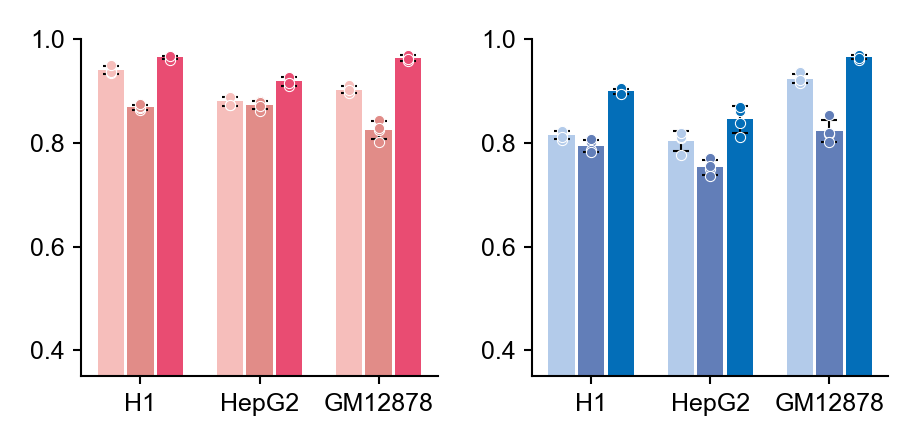

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================
# data
# =========================
targets = ['bf_label','bs_label']

data = pd.read_csv('benchmarks/revised_v2/reviewer3/results/bs_bf_threshold_analysis_indicators.csv')
data_baseline = pd.read_csv('extra/results/bs_bf_para_indicators.csv')

data_baseline['threshold_method'] = 'median'
data.drop(columns=['infer_method'], inplace=True)

indicators = pd.concat([data, data_baseline], axis=0)
indicators['auc'] = indicators['auc'] / 100


# =========================
# plot setup
# =========================
fig, ax = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(8/2.54, 4/2.54)
)

order = ['E003','E118','E116']
hue_order = ['median','mean_threshold','exclude_mid20']

x_base = np.arange(len(order))

# =========================================================
# GLOBAL GEOMETRY CONTROL (核心)
# =========================================================
hue_spacing = 0.5
bar_width = 0.22
offsets = np.linspace(-hue_spacing/2, hue_spacing/2, len(hue_order))


# =========================================================
# COLOR SYSTEM (semantic 2D mapping)
# =========================================================
palette_dict = {
    'bf_label': ['#F6BEBB', "#E18C88", "#E94C72"],
    'bs_label': ['#B3CBEA', "#627EB8", "#036EB8"]
}


# =========================================================
# MAIN LOOP
# =========================================================
for idx, target in enumerate(targets):

    sub_data = indicators[indicators['target'] == target]
    summary = sub_data.groupby(['eid', 'threshold_method'])['auc'].agg(['mean','std']).reset_index()

    # -------------------------
    # BAR + ERRORBAR
    # -------------------------
    for i, method in enumerate(hue_order):

        sub = summary[summary['threshold_method'] == method]

        means = np.array([sub[sub['eid'] == eid]['mean'].values[0] for eid in order])
        stds  = np.array([sub[sub['eid'] == eid]['std'].values[0] for eid in order])

        xpos = x_base + offsets[i]

        ax[idx].bar(
            xpos,
            means,
            width=bar_width,
            color=palette_dict[target][i],
            alpha=1.0,
            linewidth=0.0,
            edgecolor='none'
        )

        ax[idx].errorbar(
            xpos,
            means,
            yerr=stds,
            fmt='none',
            ecolor='black',
            elinewidth=0.5,
            capsize=2,
            capthick=0.5,
            zorder=2
        )

    # -------------------------
    # DOTPLOT (manual scatter)
    # -------------------------
    for i, method in enumerate(hue_order):

        sub_raw = sub_data[sub_data['threshold_method'] == method]

        x = np.array([
            np.where(np.array(order) == eid)[0][0]
            for eid in sub_raw['eid']
        ])

        x = x + offsets[i]

        ax[idx].scatter(
            x,
            sub_raw['auc'].values,
            s=6,
            alpha=1.0,
            color=palette_dict[target][i],
            edgecolor="white",
            linewidth=0.25,
            zorder=3
        )

    # -------------------------
    # formatting
    # -------------------------
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(0.35, 1.0)
    ax[idx].set_xticks(x_base)
    ax[idx].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], rotation=0)

    ax[idx].legend().remove()


# =========================
# LEGEND (semantic grouping)
# =========================
legend_patches = [
    mpatches.Patch(color='#E94C72', label='BF (median)'),
    mpatches.Patch(color='#E18C88', label='BF (mean threshold)'),
    mpatches.Patch(color='#F6BEBB', label='BF (exclude mid20)'),
    mpatches.Patch(color='#036EB8', label='BS (median)'),
    mpatches.Patch(color='#627EB8', label='BS (mean threshold)'),
    mpatches.Patch(color='#B3CBEA', label='BS (exclude mid20)'),
]

fig.legend(handles=legend_patches, loc='upper center', ncol=3, frameon=False).remove()


# =========================
# save
# =========================
plt.tight_layout()

plt.savefig(
    "benchmarks/revised_v2/reviewer3/figures/threshold_analysis_txburst.pdf",
    format='pdf',
    bbox_inches='tight'
)

plt.show()

# deepcycle txburst

# deeptx

In [6]:
targets=['bf_label','bs_label']
with open('benchmarks/revised_v2/reviewer3/results/bs_bf_threshold_deeptx_analysis_indicators.csv','w') as w:
    line = ['eid','fold','auc','target','infer_method','threshold_method']
    w.write(','.join(line) + '\n')
    for eid in ["E003","E118","E116"]:    
            for fold in [0,1,2,3]:
                checkpoints = f"benchmarks/revised_v2/reviewer3/checkpoints/{eid}.threshold_mean.deeptx.fold.{fold}.bs_bf_para.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                for target in targets:
                    auc = ckpt[f"{target}_val_auc"]
                    line = [eid,str(fold),str(auc),target,'txburst','mean_threshold']
                    w.write(','.join(line) + '\n')
                checkpoints = f"benchmarks/revised_v2/reviewer3/checkpoints/{eid}.threshold_median_exclude_mid20.deeptx.fold.{fold}.bs_bf_para.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                for target in targets:
                    auc = ckpt[f"{target}_val_auc"]
                    line = [eid,str(fold),str(auc),target,'txburst','exclude_mid20']
                    w.write(','.join(line) + '\n')


data = pd.read_csv('benchmarks/revised_v2/reviewer3/results/bs_bf_threshold_deeptx_analysis_indicators.csv')
data


data_baseline = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_25448/2495089827.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[idx].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_25448/2495089827.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[idx].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_25448/2495089827.py:56: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


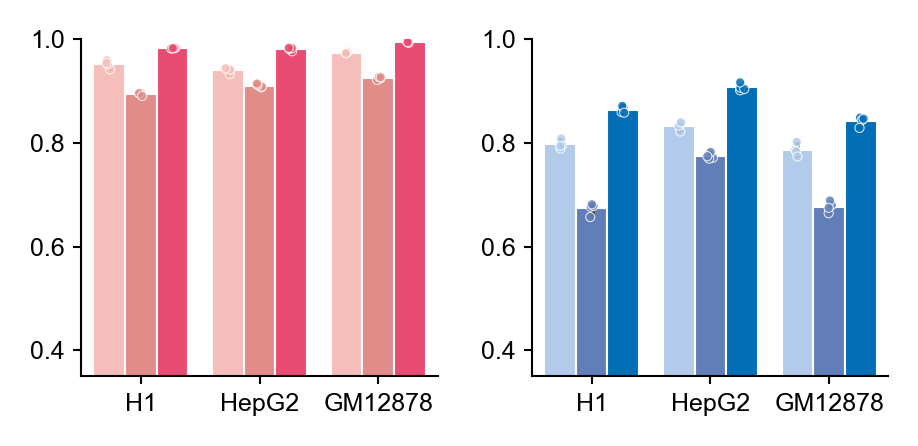

In [7]:
data = pd.read_csv('benchmarks/revised_v2/reviewer3/results/bs_bf_threshold_deeptx_analysis_indicators.csv')
data_baseline = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
data_baseline['threshold_method'] = 'median'
data.drop(columns=['infer_method'],inplace=True)
indicators = pd.concat([data,data_baseline],axis=0)

indicators['auc'] = indicators['auc']/100

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(8/2.54, 4/2.54))


palette = ['#E94C72','#036EB8','#036EB8']

order=['E003','E118','E116',]
hue_order=['median','mean_threshold','exclude_mid20',]


palette_dict = {'bf_label': ['#F6BEBB',"#E18C88","#E94C72"],'bs_label': ['#B3CBEA',"#627EB8","#036EB8"]}


for idx, target in enumerate(targets):
    sns.barplot(data=indicators[indicators['target']==target],
                x='eid',
                y='auc',
                hue='threshold_method',
                ax=ax[idx],
                order=order,
                hue_order=hue_order,
                palette=palette_dict[target],
                width=0.8,alpha=1.0,saturation=1,linewidth=0.5
                )
    sns.stripplot(
        data=indicators[indicators['target']==target],
        x="eid",
        y="auc",
        hue='threshold_method',
        order=order,
        hue_order=hue_order,
        palette=palette_dict[target],
        dodge=True,
        jitter=0.08,
        size=2.2,
        alpha=0.85,
        linewidth=0.25,
        edgecolor="white",
        ax=ax[idx],
        legend=False,
    )
    # Show the plot
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(ymin=0.35, ymax=1.0)
    ax[idx].legend().remove()
    ax[idx].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)

plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer3/figures/threshold_analysis_deeptx.pdf", format='pdf', bbox_inches='tight')
plt.show()


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74521/2735885410.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74521/2735885410.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[idx].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74521/2735885410.py:149: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


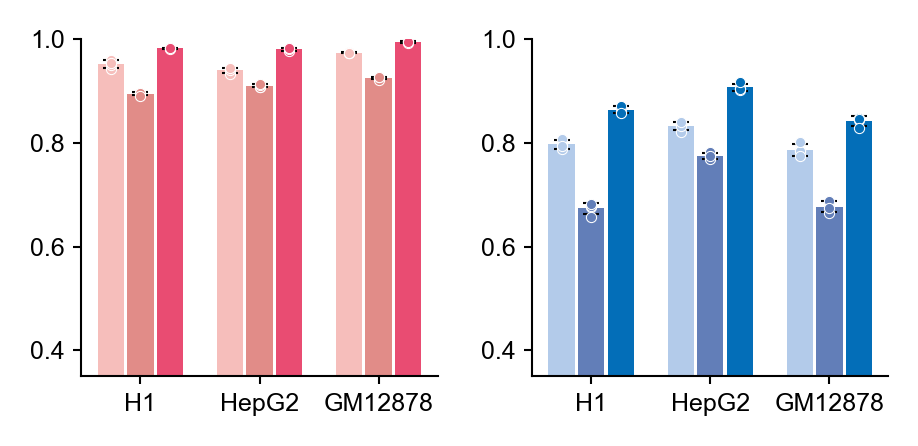

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================
# data
# =========================
targets = ['bf_label','bs_label']

data = pd.read_csv('benchmarks/revised_v2/reviewer3/results/bs_bf_threshold_deeptx_analysis_indicators.csv')
data_baseline = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')

data_baseline['threshold_method'] = 'median'
data.drop(columns=['infer_method'], inplace=True)

indicators = pd.concat([data, data_baseline], axis=0)
indicators['auc'] = indicators['auc'] / 100


# =========================
# plot setup
# =========================
fig, ax = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(8/2.54, 4/2.54)
)

order = ['E003','E118','E116']
hue_order = ['median','mean_threshold','exclude_mid20']

x_base = np.arange(len(order))

# =========================================================
# GLOBAL GEOMETRY CONTROL (核心)
# =========================================================
hue_spacing = 0.5
bar_width = 0.22
offsets = np.linspace(-hue_spacing/2, hue_spacing/2, len(hue_order))


# =========================================================
# COLOR SYSTEM (semantic 2D mapping)
# =========================================================
palette_dict = {
    'bf_label': ['#F6BEBB', "#E18C88", "#E94C72"],
    'bs_label': ['#B3CBEA', "#627EB8", "#036EB8"]
}


# =========================================================
# MAIN LOOP
# =========================================================
for idx, target in enumerate(targets):

    sub_data = indicators[indicators['target'] == target]
    summary = sub_data.groupby(['eid', 'threshold_method'])['auc'].agg(['mean','std']).reset_index()

    # -------------------------
    # BAR + ERRORBAR
    # -------------------------
    for i, method in enumerate(hue_order):

        sub = summary[summary['threshold_method'] == method]

        means = np.array([sub[sub['eid'] == eid]['mean'].values[0] for eid in order])
        stds  = np.array([sub[sub['eid'] == eid]['std'].values[0] for eid in order])

        xpos = x_base + offsets[i]

        ax[idx].bar(
            xpos,
            means,
            width=bar_width,
            color=palette_dict[target][i],
            alpha=1.0,
            linewidth=0.0,
            edgecolor='none'
        )

        ax[idx].errorbar(
            xpos,
            means,
            yerr=stds,
            fmt='none',
            ecolor='black',
            elinewidth=0.5,
            capsize=2,
            capthick=0.5,
            zorder=2
        )

    # -------------------------
    # DOTPLOT (manual scatter)
    # -------------------------
    for i, method in enumerate(hue_order):

        sub_raw = sub_data[sub_data['threshold_method'] == method]

        x = np.array([
            np.where(np.array(order) == eid)[0][0]
            for eid in sub_raw['eid']
        ])

        x = x + offsets[i]

        ax[idx].scatter(
            x,
            sub_raw['auc'].values,
            s=6,
            alpha=1.0,
            color=palette_dict[target][i],
            edgecolor="white",
            linewidth=0.25,
            zorder=3
        )

    # -------------------------
    # formatting
    # -------------------------
    ax[idx].set_ylabel("")
    ax[idx].set_xlabel("")
    ax[idx].set_ylim(0.35, 1.0)
    ax[idx].set_xticks(x_base)
    ax[idx].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], rotation=0)

    ax[idx].legend().remove()


# =========================
# LEGEND (semantic grouping)
# =========================
legend_patches = [
    mpatches.Patch(color='#E94C72', label='BF (median)'),
    mpatches.Patch(color='#E18C88', label='BF (mean threshold)'),
    mpatches.Patch(color='#F6BEBB', label='BF (exclude mid20)'),
    mpatches.Patch(color='#036EB8', label='BS (median)'),
    mpatches.Patch(color='#627EB8', label='BS (mean threshold)'),
    mpatches.Patch(color='#B3CBEA', label='BS (exclude mid20)'),
]

fig.legend(handles=legend_patches, loc='upper center', ncol=3, frameon=False).remove()


# =========================
# save
# =========================
plt.tight_layout()

plt.savefig(
    "benchmarks/revised_v2/reviewer3/figures/threshold_analysis_deeptx.pdf",
    format='pdf',
    bbox_inches='tight'
)

plt.show()